In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [40]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/cleaned_flights.csv')

Mounted at /content/drive


/tmp/ipykernel_519/3592577965.py:4: DtypeWarning:

Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.



In [41]:
# Remove cancelled flights for delay analysis
delay_df = df[df["CANCELLED"] == 0]

In [42]:
# Convert airport columns to string
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype(str)
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype(str)

# Create route column
df['ROUTE'] = df['ORIGIN_AIRPORT'] + " - " + df['DESTINATION_AIRPORT']

In [ ]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,FLIGHT_DATE,DEPARTURE_TIME_BEFORE,MONTH_BEFORE,MONTH_AFTER,HOUR_AFTER,ROUTE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,NaN,NaN,NaN,2015-01-01,2354.0,1,1,23.0,ANC - SEA
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,NaN,NaN,NaN,2015-01-01,2.0,1,1,0.0,LAX - PBI
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,NaN,NaN,NaN,2015-01-01,18.0,1,1,0.0,SFO - CLT
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,NaN,NaN,NaN,2015-01-01,15.0,1,1,0.0,LAX - MIA
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,NaN,NaN,NaN,2015-01-01,24.0,1,1,0.0,SEA - ANC


/tmp/ipykernel_519/2774038009.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




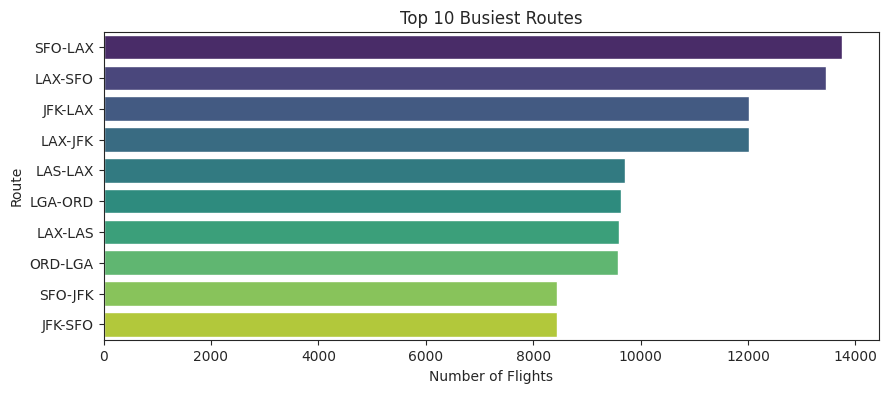

Conclusion: The busiest route is SFO-LAX with 13744 flights, indicating a high traffic corridor between these airports.


In [33]:
# -------- Top 10 Origin - Destination Pairs --------
top_routes = df["ROUTE"].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_routes.values, y=top_routes.index, palette="viridis")

plt.title("Top 10 Busiest Routes")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.savefig("Origin Dest Pair.png", dpi=300, bbox_inches="tight")
plt.show()

# Data-driven conclusion
most_busy = top_routes.idxmax()
max_flights = top_routes.max()

print(f"Conclusion: The busiest route is {most_busy} with {max_flights} flights, indicating a high traffic corridor between these airports.")

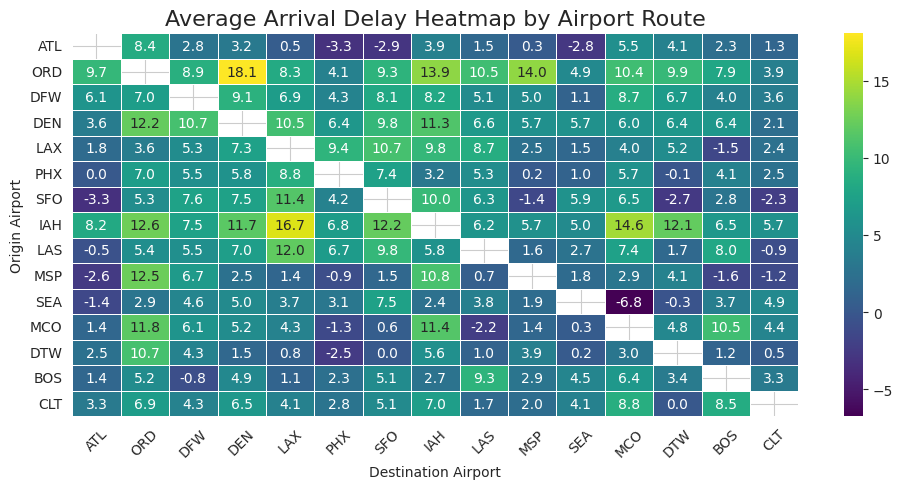

Conclusion: The route with the highest average delay is ORD → DEN with 18.07 minutes delay.


In [43]:
# -------- DELAY HEATMAP BY ROUTE --------
# Create pivot table (Origin vs Destination)
route_delay = delay_df.pivot_table(
    values='ARRIVAL_DELAY',
    index='ORIGIN_AIRPORT',
    columns='DESTINATION_AIRPORT',
    aggfunc='mean'
)

# Limit to top airports for readability
top_airports = delay_df['ORIGIN_AIRPORT'].value_counts().head(15).index
route_delay = route_delay.loc[top_airports, top_airports]

# Plot Heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    route_delay,
    annot=True,          # shows numbers inside cells
    fmt=".1f",           # format numbers
    cmap="viridis",     # vibrant color palette
    linewidths=0.5,
    linecolor='white'
)

plt.title("Average Arrival Delay Heatmap by Airport Route", fontsize=16)
plt.xlabel("Destination Airport")
plt.ylabel("Origin Airport")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("route delay heatmap airport.png", dpi=300, bbox_inches="tight")
plt.show()

# Extract key insight
max_route = route_delay.stack().idxmax()
max_delay = route_delay.stack().max()

print(f"Conclusion: The route with the highest average delay is {max_route[0]} → {max_route[1]} with {max_delay:.2f} minutes delay.")

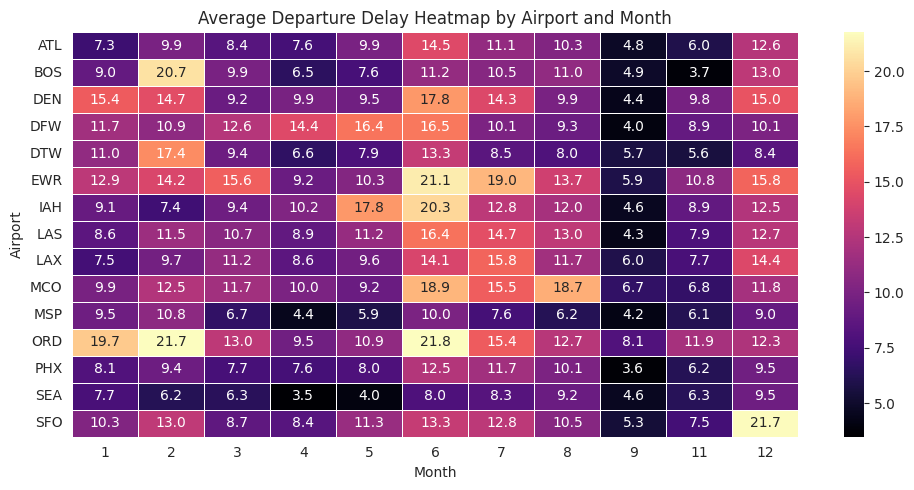

Conclusion: Airport ORD in month 6 shows the highest average delay of 21.75 minutes.


In [44]:
# -------- DELAY HEATMAP BY AIRPORT --------
# Select top 15 busiest airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(15).index

# Filter dataset
filtered_df = delay_df[delay_df['ORIGIN_AIRPORT'].isin(top_airports)]

# Create pivot table (Airport vs Month)
airport_delay = filtered_df.pivot_table(
    values='DEPARTURE_DELAY',
    index='ORIGIN_AIRPORT',
    columns='MONTH',
    aggfunc='mean'
)

# Plot Heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    airport_delay,
    annot=True,          # numbers inside cells
    fmt=".1f",
    cmap="magma",     # vibrant colors
    linewidths=0.5,
    linecolor="white"
)
plt.title("Average Departure Delay Heatmap by Airport and Month")
plt.xlabel("Month")
plt.ylabel("Airport")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("airport delay heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
max_delay_airport = airport_delay.stack().idxmax()
max_delay_value = airport_delay.stack().max()

print(f"Conclusion: Airport {max_delay_airport[0]} in month {max_delay_airport[1]} shows the highest average delay of {max_delay_value:.2f} minutes.")

In [46]:
# -------- Maps showing busiest airports and average delays --------
# Airport statistics
airport_stats = df.groupby("ORIGIN_AIRPORT").agg(
    Flights=("ORIGIN_AIRPORT", "count"),
    Avg_Delay=("ARRIVAL_DELAY", "mean")
).reset_index()

# Top busiest airports
top_airports = airport_stats.sort_values("Flights", ascending=False).head(15)

# Airport coordinates
coords = {
'ATL':[33.64,-84.42],'LAX':[33.94,-118.40],'ORD':[41.97,-87.90],
'DFW':[32.89,-97.04],'DEN':[39.85,-104.67],'JFK':[40.64,-73.77],
'SFO':[37.62,-122.37],'SEA':[47.45,-122.30],'LAS':[36.08,-115.15],
'MCO':[28.43,-81.30],'EWR':[40.68,-74.17],'CLT':[35.21,-80.94],
'PHX':[33.43,-112.01],'IAH':[29.99,-95.33],'MIA':[25.79,-80.28]
}

top_airports["lat"] = top_airports["ORIGIN_AIRPORT"].map(lambda x: coords.get(x,[None,None])[0])
top_airports["lon"] = top_airports["ORIGIN_AIRPORT"].map(lambda x: coords.get(x,[None,None])[1])

# Create map
fig = px.scatter_geo(
    top_airports,
    lat="lat",
    lon="lon",
    size="Flights",
    color="Avg_Delay",
    hover_name="ORIGIN_AIRPORT",
    projection="natural earth",
    color_continuous_scale="Plasma",
    title="Map of Busiest Airports and Average Arrival Delays"
)

# Change background map colors
fig.update_geos(
    showland=True,
    landcolor="lightgreen",     # land color
    showocean=True,
    oceancolor="lightblue",     # ocean color
    showlakes=True,
    lakecolor="lightblue",
    showcountries=True,
    countrycolor="black"
)

fig.show()

# Observations
busiest = top_airports.loc[top_airports["Flights"].idxmax()]
highest_delay = top_airports.loc[top_airports["Avg_Delay"].idxmax()]
lowest_delay = top_airports.loc[top_airports["Avg_Delay"].idxmin()]
corr = airport_stats["Flights"].corr(airport_stats["Avg_Delay"])

print("\nObservations:\n")
print(f"1. {busiest['ORIGIN_AIRPORT']} is the busiest airport with {busiest['Flights']} flights.")
print(f"2. {highest_delay['ORIGIN_AIRPORT']} has the highest average delay ({highest_delay['Avg_Delay']:.2f} minutes).")
print(f"3. {lowest_delay['ORIGIN_AIRPORT']} has the lowest average delay ({lowest_delay['Avg_Delay']:.2f} minutes).")
print(f"4. Correlation between airport traffic and delay: {corr:.2f}")
print("5. Larger bubbles indicate busier airports, while brighter colors represent higher delays.")


Observations:

1. ATL is the busiest airport with 346836 flights.
2. ORD has the highest average delay (8.32 minutes).
3. MSP has the lowest average delay (1.95 minutes).
4. Correlation between airport traffic and delay: 0.09
5. Larger bubbles indicate busier airports, while brighter colors represent higher delays.


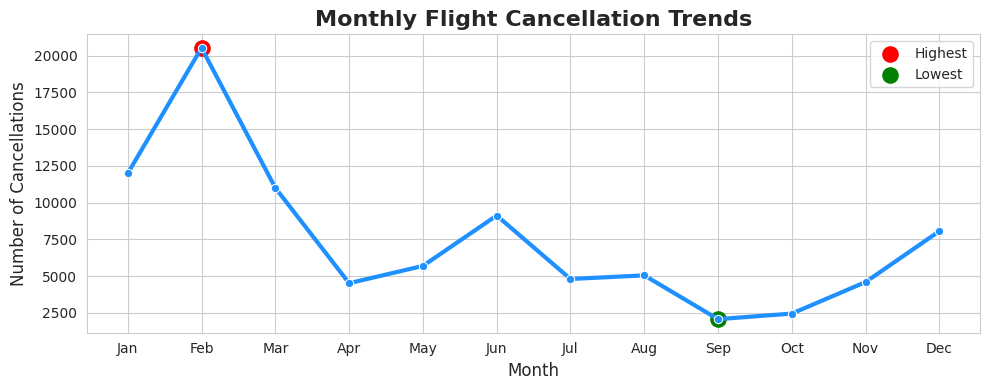


Observations:
Highest cancellations occurred in month 2.
Lowest cancellations occurred in month 9.
Seasonal weather and operational issues may contribute to higher cancellations in peak months.


In [35]:
# -------- Monthly cancellation trends --------
# Filter cancelled flights
cancelled = df[df["CANCELLED"] == 1]

# Monthly cancellation count
monthly_cancel = cancelled.groupby("MONTH").size()

# Style
sns.set_style("whitegrid")
plt.figure(figsize=(10,4))

# Line plot
sns.lineplot(
    x=monthly_cancel.index,
    y=monthly_cancel.values,
    marker="o",
    linewidth=3,
    color="dodgerblue"
)

# Highlight highest and lowest points
max_month = monthly_cancel.idxmax()
min_month = monthly_cancel.idxmin()

plt.scatter(max_month, monthly_cancel[max_month], color="red", s=120, label="Highest")
plt.scatter(min_month, monthly_cancel[min_month], color="green", s=120, label="Lowest")

# Labels and title
plt.title("Monthly Flight Cancellation Trends", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Cancellations", fontsize=12)

# Month names
plt.xticks(range(1,13),
["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

plt.legend()
plt.tight_layout()
plt.savefig("monthly cancellation trends.png", dpi=300, bbox_inches="tight")
plt.show()

# Observations
print("\nObservations:")
print(f"Highest cancellations occurred in month {max_month}.")
print(f"Lowest cancellations occurred in month {min_month}.")
print("Seasonal weather and operational issues may contribute to higher cancellations in peak months.")

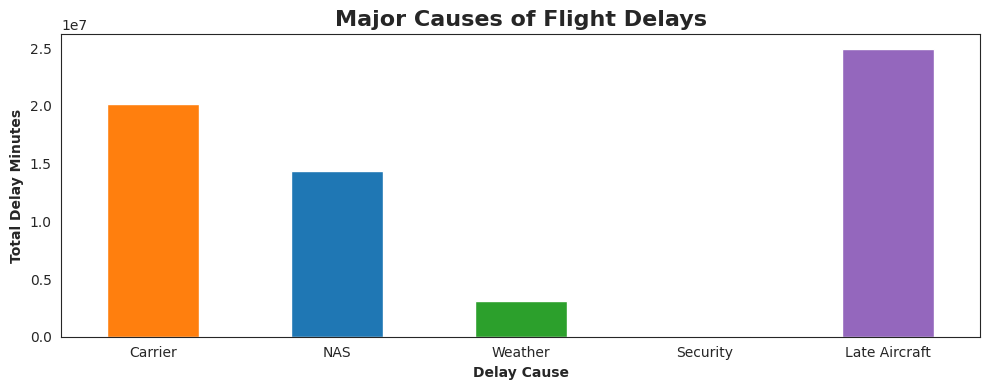


Observations from the Analysis:

1. The largest contributor to delays is LATE_AIRCRAFT_DELAY.
2. The least significant delay factor is SECURITY_DELAY.
3. Operational issues such as carrier delays and late aircraft contribute heavily to disruptions.
4. Security-related delays are comparatively minimal in airline operations.


In [36]:
# -------- Cancellation types: carrier, weather, security, NAS --------
delay_causes = df[[
    "AIRLINE_DELAY",
    "AIR_SYSTEM_DELAY",
    "WEATHER_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]].sum()

sns.set_style("white")

plt.figure(figsize=(10,4))

delay_causes.plot(
    kind="bar",
    color=["#ff7f0e","#1f77b4","#2ca02c","#d62728","#9467bd"]
)

plt.title("Major Causes of Flight Delays", fontsize=16, weight="bold")
plt.xlabel("Delay Cause", weight="bold")
plt.ylabel("Total Delay Minutes", weight="bold")

plt.xticks(
    ticks=range(len(delay_causes)),
    labels=["Carrier","NAS","Weather","Security","Late Aircraft"],
    rotation=0
)

plt.tight_layout()
plt.savefig("cause of flight delay.png", dpi=300, bbox_inches="tight")
plt.show()

# Observations
print("\nObservations from the Analysis:\n")

print(f"1. The largest contributor to delays is {delay_causes.idxmax()}.")
print(f"2. The least significant delay factor is {delay_causes.idxmin()}.")
print("3. Operational issues such as carrier delays and late aircraft contribute heavily to disruptions.")
print("4. Security-related delays are comparatively minimal in airline operations.")



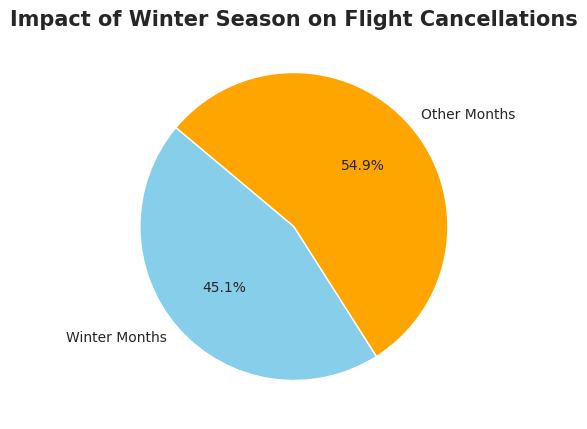


Observations:

1. Total cancellations during winter months: 40562
2. Total cancellations during other months: 49322
3. Winter months do not significantly increase cancellations compared to other months.
4. Seasonal weather patterns and peak travel demand influence airline reliability.


In [32]:

# -------- Impact of holidays or winter months --------
# Winter months
winter = df[df["MONTH"].isin([12,1,2])]
other = df[~df["MONTH"].isin([12,1,2])]

winter_cancel = winter["CANCELLED"].sum()
other_cancel = other["CANCELLED"].sum()

labels = ["Winter Months", "Other Months"]
values = [winter_cancel, other_cancel]

sns.set_style("ticks")

plt.figure(figsize=(5,5))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    colors=["skyblue","orange"],
    startangle=140
)

plt.title("Impact of Winter Season on Flight Cancellations", fontsize=15, weight="bold")

plt.show()
# Observations
print("\nObservations:\n")
print(f"1. Total cancellations during winter months: {winter_cancel}")
print(f"2. Total cancellations during other months: {other_cancel}")

if winter_cancel > other_cancel:
    print("3. Winter months show higher cancellations, likely due to weather disruptions and holiday travel congestion.")
else:
    print("3. Winter months do not significantly increase cancellations compared to other months.")

print("4. Seasonal weather patterns and peak travel demand influence airline reliability.")

